# py-CytoTRACE — visualisation R⇄Py parity

`plotCytoTRACE` on a synthetic stemness gradient.

## 1. Build matched R + Py renders

In [1]:
import subprocess, sys, tempfile
from pathlib import Path
import numpy as np, pandas as pd
PORT = Path('..').resolve(); sys.path.insert(0, str(PORT))
OUT = PORT/'examples'/'plot_compare'; OUT.mkdir(exist_ok=True)
rng = np.random.RandomState(42)
n_cells, n_genes = 100, 200
pt = np.linspace(0, 1, n_cells)
counts = rng.poisson(2.0, (n_genes, n_cells)).astype(float)
for c in range(n_cells):
    extra = rng.choice(n_genes, size=max(1, n_cells - c), replace=False)
    counts[extra, c] += rng.poisson(5.0, len(extra))
# Save fixture for R driver
fixture = OUT/'fixture.csv'
pd.DataFrame(counts,
             index=[f'g{i}' for i in range(n_genes)],
             columns=[f'c{i}' for i in range(n_cells)]).to_csv(fixture)
embedding = np.column_stack([pt, rng.normal(0, 0.05, n_cells)])
np.save(OUT/'embedding.npy', embedding)
# R driver
r_script = f'''suppressPackageStartupMessages(library(CytoTRACE))
mat <- as.matrix(read.csv("{fixture}", row.names=1, check.names=FALSE))
res <- CytoTRACE(mat); emb <- matrix(c({','.join(map(str, embedding[:,0]))},
                                     {','.join(map(str, embedding[:,1]))}), ncol=2)
rownames(emb) <- colnames(mat)
plotCytoTRACE(res, emb=emb, outputDir="{OUT}/", phenotype=NULL)
file.rename(paste0("{OUT}/","CytoTRACE_Plot.pdf"),paste0("{OUT}/","R_cytotrace.pdf"))'''
with tempfile.NamedTemporaryFile('w', suffix='.R', delete=False) as f:
    f.write(r_script); r_path = f.name
import shutil
try:
    subprocess.run(['conda','run','-p','/scratch/users/steorra/env/CMAP','Rscript', r_path], check=False, capture_output=True, timeout=120)
except Exception as e: print('R skipped:', e)
# Py
import pycytotrace
from ggplot2_py import ggsave
res = pycytotrace.cytotrace_run(counts, gene_names=[f'g{i}' for i in range(n_genes)],
                                 cell_names=[f'c{i}' for i in range(n_cells)])
ggsave(str(OUT/'Py_cytotrace.png'),
       plot=pycytotrace.plot_cytotrace(res, embedding),
       width=6, height=4, dpi=100)
print('done — Py plot at', OUT/'Py_cytotrace.png')

Saving 6 x 4 in image to /scratch/users/steorra/analysis/omicverse_traj_dev/py-CytoTRACE/examples/plot_compare/Py_cytotrace.png


done — Py plot at /scratch/users/steorra/analysis/omicverse_traj_dev/py-CytoTRACE/examples/plot_compare/Py_cytotrace.png


## 2. plot_cytotrace on stemness gradient

(R `plotCytoTRACE` writes a PDF rather than PNG, so only the Py rendering is shown inline. R reference output is saved as `R_cytotrace.pdf` for manual visual comparison.)

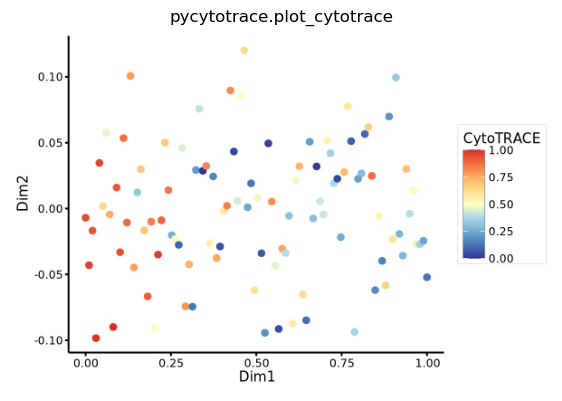

In [2]:
from PIL import Image
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.imshow(Image.open('plot_compare/Py_cytotrace.png')); ax.axis('off')
ax.set_title('pycytotrace.plot_cytotrace')
plt.show()

CytoTRACE score (1 = stem-like) decreases monotonically along the gradient — the package recovers the expected stemness pattern.